*第一部分：回归与分类*

In [2]:
import torch
import torch.nn as nn
model = nn.Linear(in_features=2, out_features=1)

print("weight = ", model.weight)
print("bias = ", model.bias)

weight =  Parameter containing:
tensor([[-0.2554, -0.6242]], requires_grad=True)
bias =  Parameter containing:
tensor([-0.5696], requires_grad=True)


In [3]:
li = [[100, 3], [120, 4], [80, 2]]
T = torch.tensor(li, dtype=torch.float32)
print(type(T))
print(T)

<class 'torch.Tensor'>
tensor([[100.,   3.],
        [120.,   4.],
        [ 80.,   2.]])


In [4]:
prediction = model(T)

print("prediction : ", prediction)
print("prediction's shape : ", prediction.shape)

prediction :  tensor([[-27.9773],
        [-33.7086],
        [-22.2461]], grad_fn=<AddmmBackward0>)
prediction's shape :  torch.Size([3, 1])


In [5]:
import torch.nn.functional as F
# 计算误差

# 真实价格
y_true = torch.tensor([[120.0], [150.0], [90.0]])
loss = F.mse_loss(prediction, y_true)
print(loss)

tensor(22748.4316, grad_fn=<MseLossBackward0>)


In [ ]:
import torch.optim as optim

# 定义优化器(随机梯度下降SGD)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 将model的参数用lr学习率进行随机梯度下降

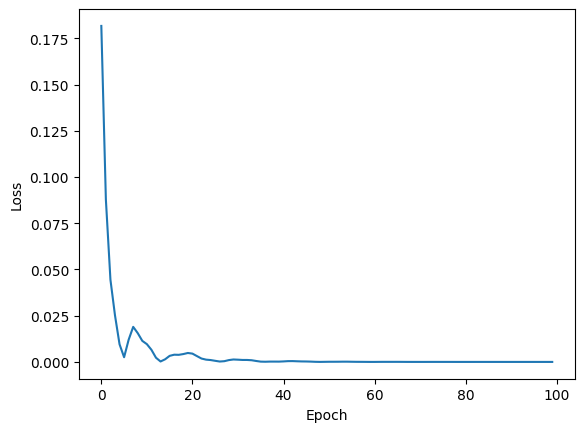

loss =  tensor(4.9911e-08, grad_fn=<MseLossBackward0>)


In [19]:
# 把上面的串起来
# 线性回归 + 归一化：
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt

def normalize(data : torch.Tensor) -> torch.Tensor:
    data_min = data.min(dim=0).values
    data_max = data.max(dim=0).values
    return (data - data_min) / (data_max - data_min)

T = torch.tensor([[100, 3], [120, 4], [80, 2]], dtype=torch.float32) # 初始数据
y_true = torch.tensor([[120.0], [150.0], [90.0]]) # 真实数据

T_norm = normalize(T)
y_true_norm = normalize(y_true)

# model = nn.Linear(in_features=2, out_features=1)
model = nn.Sequential(
    nn.Linear(2, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
optimizer = optim.Adam(model.parameters(), lr=0.008)
losses = []

for epoch in range(100):
    # 1. 清空旧账本
    optimizer.zero_grad()

    # 2. 猜一次
    prediction = model(T_norm)

    # 3. 算误差
    loss = F.mse_loss(prediction, y_true_norm)

    # 4. 反向传播(倒着走), 算梯度
    loss.backward()

    # 5. 更新参数
    optimizer.step()

    # 6. 记录loss(转换为普通的Python数字)
    losses.append(loss.item())


plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


print("loss = ", loss)

下面引入激活函数

在理论上，神经元越多，模型确实能记住更复杂的细节，变得更“聪明”。但这种聪明是有代价的，可能会出现以下两种有趣的情况：

1. 记忆力 vs 理解力 (Overfitting) 🧠
如果神经元过多，模型可能会开始“死记硬背”训练数据中的每一个噪声和细节，而不是学习背后的通用规律。这就像一个学生背下了所有练习题的答案，但考试题稍微变个数字就不会做了。这种现象叫作过拟合。

2. 训练难度增加 (Computational Cost) ⏳
神经元越多，电脑需要进行的数学运算就呈几何倍数增长。如果你的数据量很小（比如我们现在只有 3 条房产信息），给它 100 个神经元就像是雇佣了 100 个顶级教授来研究一个小学的加减法——不仅大材小用，还可能因为意见太多反而算得很慢。

In [ ]:
import torch.nn as nn

model2 = nn.Sequential(
    nn.Linear(2, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
# 由于神经元、参数增加了，需要增加训练次数才能更好的拟合；保持较小的学习率，因为学习过程变精细了


接下来：划分训练集和验证集·

In [27]:
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

T = torch.tensor([[100, 3], [120, 4], [80, 2], [150, 5], [90, 3]], dtype=torch.float32)
y = torch.tensor([[120.0], [150.0], [90.0], [200.0], [105.0]])

def normalize(data : torch.Tensor) -> torch.Tensor:
    data_min = data.min(dim=0).values
    data_max = data.max(dim=0).values
    return (data - data_min) / (data_max - data_min)

T_norm = normalize(T)
y_norm = normalize(y)

T_train, T_val = T_norm[:4], T_norm[4:]
y_train, y_val = y_norm[:4], y_norm[4:]

model = nn.Sequential(
    nn.Linear(2, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)
optimizer = optim.Adam(model.parameters(), lr=0.01)
# losses = []

for epoch in range(2000):

    model.train() # 切换到训练模式
    optimizer.zero_grad()

    pred_train = model(T_train)
    loss_train = F.mse_loss(pred_train, y_train)

    loss_train.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        model.eval() # 切换到评估模式
        with torch.no_grad(): # ！！！ 不记录梯度，不更新权重
            pred_val = model(T_val)
            loss_val = F.mse_loss(pred_val, y_val)
        print(f"Epoch [{epoch+1}/2000], Train Loss: {loss_train.item():.6f}, Val Loss: {loss_val.item():.6f}")
    # losses.append(loss_train.item())

# plt.plot(losses)
# plt.xlabel('epoch')
# plt.ylabel('loss')
# plt.show()



Epoch [100/2000], Train Loss: 0.000001, Val Loss: 0.002146
Epoch [200/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [300/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [400/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [500/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [600/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [700/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [800/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [900/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [1000/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [1100/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [1200/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [1300/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [1400/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [1500/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [1600/2000], Train Loss: 0.000000, Val Loss: 0.002278
Epoch [1700/2000], Train Loss: 0.000000, Val Loss

面对真实数据流：dataloader

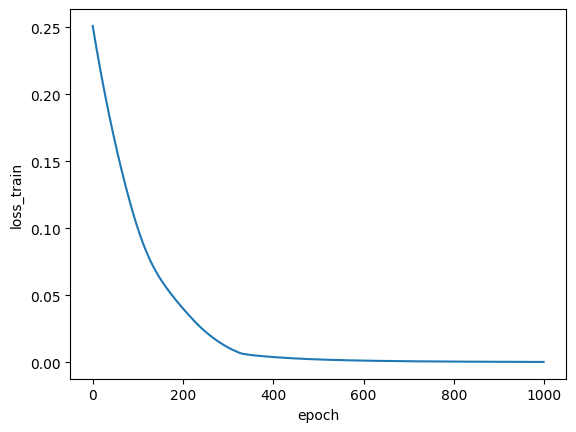

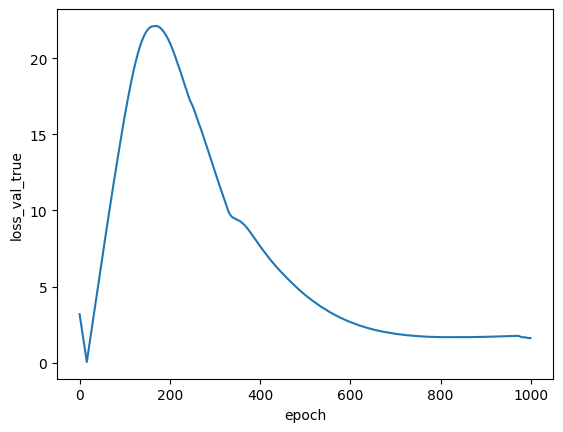

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

T = torch.tensor([[100, 3], [120, 4], [80, 2], [150, 5], [90, 3]], dtype=torch.float32)
y = torch.tensor([[120.0], [150.0], [90.0], [200.0], [105.0]])

def normalize(data : torch.Tensor) -> torch.Tensor:
    data_min = data.min(dim=0).values
    data_max = data.max(dim=0).values
    return (data - data_min) / (data_max - data_min)
# 提取最值用于还原
y_min = y.min(dim=0).values
y_max = y.max(dim=0).values

T_norm = normalize(T)
y_norm = normalize(y)

T_train, T_val = T_norm[:4], T_norm[4:]
y_train, y_val = y_norm[:4], y_norm[4:]

model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)
optimizer = optim.Adam(model.parameters(), lr=0.001)
losses_train = []
losses_val_true = []
# 上面数据预处理一样

# 1. 将训练用的张量打包成一个数据集
train_dataset = TensorDataset(T_train, y_train)

# 2. 创建数据加载器： 每批处理2条数据，并且每一轮都打乱顺序
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)


for epoch in range(1000):
    model.train()

    for batch_T, batch_y in train_loader:
        optimizer.zero_grad()
        
        prediction = model(batch_T)
        loss = F.mse_loss(prediction, batch_y)

        loss.backward()
        optimizer.step()

        losses_train.append(loss.item())

    # 评估模式
    model.eval()
    with torch.no_grad():
        pred_norm = model(T_val)

        pred_real = pred_norm * (y_max - y_min) + y_min
        y_real = y_val * (y_max - y_min) + y_min

        mse_loss = torch.abs(pred_real - y_real).mean()

        losses_val_true.append(mse_loss.item())

plt.plot(losses_train)
plt.xlabel('epoch')      
plt.ylabel('loss_train')  
plt.show()

plt.plot(losses_val_true)
plt.xlabel('epoch')      
plt.ylabel('loss_val_true')  
plt.show()


重点：
batch_size 大：
- 一次性看完很多数据，更新一次参数。
- 结果：更稳，下降平缓; 一次性把数据塞进内存，硬件负担大；容易陷入局部最优。
    
batch_size 小：
- 看较少数据就更新参数，更新频率高。
- 结果：更抖，下降更快；对硬件友好；更容易找到全局最优。
`

权重衰减：L2正则化:在损失函数中加入一个惩罚项，如果模型的权重 $w$ 变得太大，Loss 就会变高。

这迫使模型在训练时保持权重的数值尽可能小且平滑。这能有效防止某个权重为了去“迎合”某条特定数据而变得异常巨大。

In [ ]:
# 这里的 weight_decay 就是 L2 正则化的系数
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

2. 早停法 (Early Stopping) 🛑
早停法更像是一个“智能裁判”。它会一直盯着 losses_val_true。如果发现验证集 Loss 连续好几个回合（比如 50 个 Epoch）都没有再创新低，它就会判定模型已经开始过拟合了，直接强制结束程序。

为了实现这个，我们需要在代码中定义两个变量：

best_loss：记录目前为止见过的最低验证集损失。

patience（耐心值）：允许验证集不达标的最大次数。

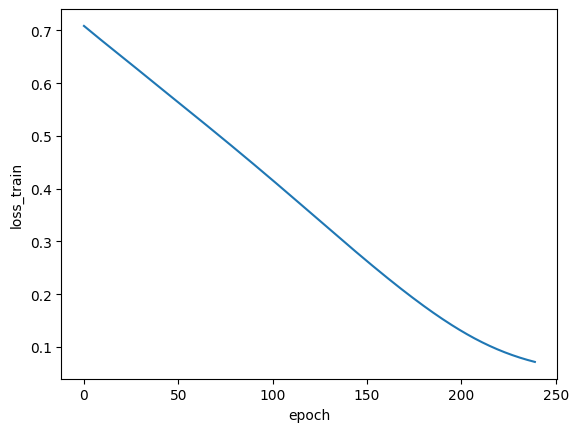

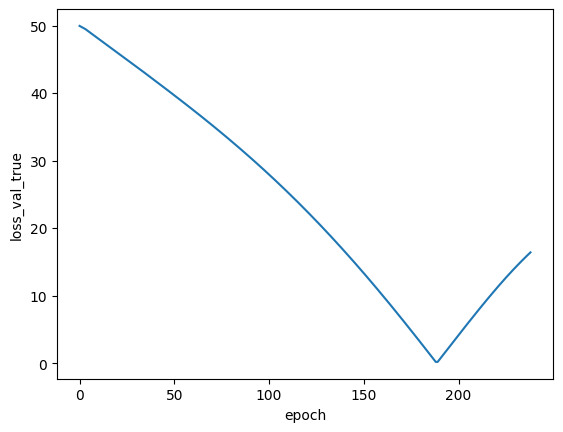

训练停止！最好成绩 (MAE): 0.1784
最后一套房子预测价格为：121.66365051269531 万元


In [75]:
T = torch.tensor([[100, 3], [120, 4], [80, 2], [150, 5], [90, 3]], dtype=torch.float32)
y = torch.tensor([[120.0], [150.0], [90.0], [200.0], [105.0]])

def normalize(data : torch.Tensor) -> torch.Tensor:
    data_min = data.min(dim=0).values
    data_max = data.max(dim=0).values
    return (data - data_min) / (data_max - data_min)
# 提取最值用于还原
y_min = y.min(dim=0).values
y_max = y.max(dim=0).values

T_norm = normalize(T)
y_norm = normalize(y)

T_train, T_val = T_norm[:4], T_norm[4:]
y_train, y_val = y_norm[:4], y_norm[4:]

model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # 权重衰减系数
losses_train = []
losses_val_true = []
# 上面数据预处理一样

# 1. 将训练用的张量打包成一个数据集
train_dataset = TensorDataset(T_train, y_train)

# 2. 创建数据加载器： 每批处理2条数据，并且每一轮都打乱顺序
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Early Stopping
best_loss = 1e9
best_model_state = None
patience = 50
round = 0


for epoch in range(1000):
    model.train()

    for batch_T, batch_y in train_loader:
        optimizer.zero_grad()
        
        prediction = model(batch_T)
        loss = F.mse_loss(prediction, batch_y)

        loss.backward()
        optimizer.step()

        losses_train.append(loss.item())

    # 评估模式
    model.eval()
    with torch.no_grad():
        pred_norm = model(T_val)

        pred_real = pred_norm * (y_max - y_min) + y_min
        y_real = y_val * (y_max - y_min) + y_min

        mse_loss = torch.abs(pred_real - y_real).mean()

        if mse_loss < best_loss:
            round = 0
            best_loss = mse_loss
            best_model_state = model.state_dict()
        else:
            round = round + 1

        if round > patience:
            break

        losses_val_true.append(mse_loss.item())

plt.plot(losses_train)
plt.xlabel('epoch')      
plt.ylabel('loss_train')  
plt.show()

plt.plot(losses_val_true)
plt.xlabel('epoch')      
plt.ylabel('loss_val_true')  
plt.show()

# 训练结束后，把巅峰状态放回模型
model.load_state_dict(best_model_state)
print(f"训练停止！最好成绩 (MAE): {best_loss:.4f}")

model.eval()
with torch.no_grad():
    pred_end = model(T_val)
    print(f"最后一套房子预测价格为：{(pred_end * (y_max - y_min) + y_min).item()} 万元")

复习：
1. 避免过拟合的方法：
- 1. 正则化(L1 & L2)
- 2. 丢弃法：随机让一定比例的神经元"罢工"
- 3. 数据增强：对原始数据进行旋转、平移、裁剪或加入噪声等，人工制造出更多新数据，提升泛化能力
- 4. 提前停止：训练集误差不再下降，或者训练集误差还在下降，验证集误差却开始上升时停止训练
- 5. 权重初始化与归一化：通过LayerNorm(层归一化)将数据限制在合理范围内。